In [1]:
# ================================
# HR Attrition Predictor
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported! 🚀")

Libraries imported! 🚀


In [3]:
# Load IBM HR Analytics dataset
url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"
df = pd.read_csv(url)

print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values: {df.isnull().sum().sum()}")

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.1%


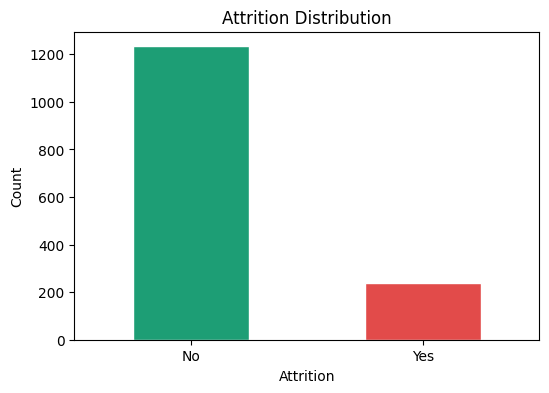

In [5]:
# Check attrition distribution
print("Attrition Distribution:")
print(df['Attrition'].value_counts())
print(f"\nAttrition Rate: {df['Attrition'].value_counts()['Yes']/len(df)*100:.1f}%")

# Plot
plt.figure(figsize=(6, 4))
df['Attrition'].value_counts().plot(kind='bar', 
                                     color=['#1D9E75', '#E24B4A'],
                                     edgecolor='white')
plt.title('Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

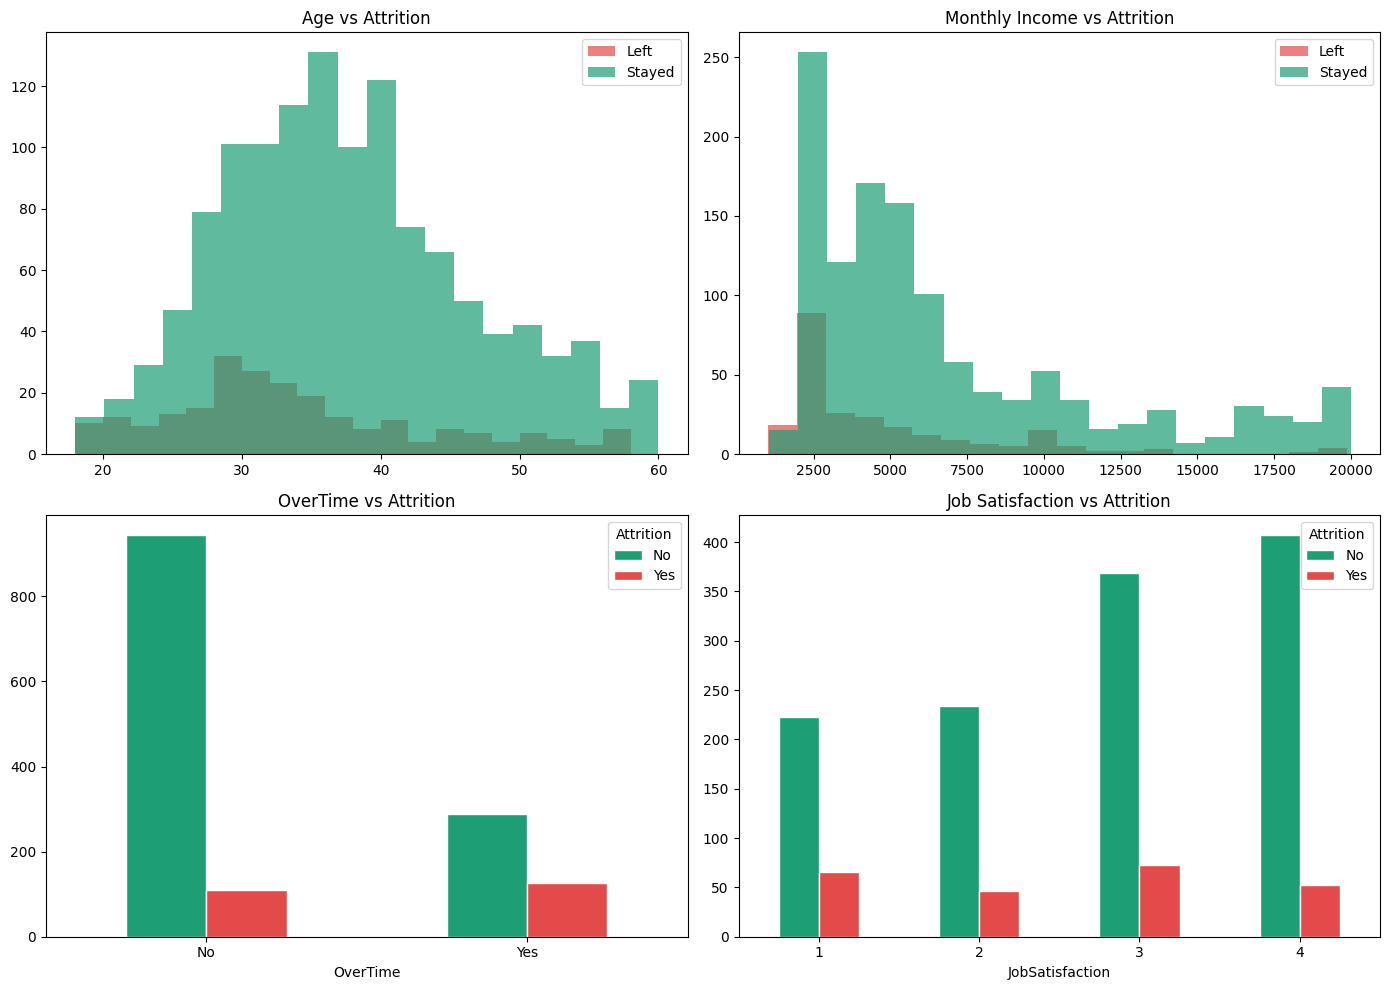

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age vs Attrition
axes[0,0].hist(df[df['Attrition']=='Yes']['Age'], 
               bins=20, alpha=0.7, color='#E24B4A', label='Left')
axes[0,0].hist(df[df['Attrition']=='No']['Age'], 
               bins=20, alpha=0.7, color='#1D9E75', label='Stayed')
axes[0,0].set_title('Age vs Attrition')
axes[0,0].legend()

# Monthly Income vs Attrition
axes[0,1].hist(df[df['Attrition']=='Yes']['MonthlyIncome'], 
               bins=20, alpha=0.7, color='#E24B4A', label='Left')
axes[0,1].hist(df[df['Attrition']=='No']['MonthlyIncome'], 
               bins=20, alpha=0.7, color='#1D9E75', label='Stayed')
axes[0,1].set_title('Monthly Income vs Attrition')
axes[0,1].legend()

# OverTime vs Attrition
overtime_attr = df.groupby(['OverTime', 'Attrition']).size().unstack()
overtime_attr.plot(kind='bar', ax=axes[1,0], 
                   color=['#1D9E75', '#E24B4A'], edgecolor='white')
axes[1,0].set_title('OverTime vs Attrition')
axes[1,0].tick_params(axis='x', rotation=0)

# Job Satisfaction vs Attrition
jobsat_attr = df.groupby(['JobSatisfaction', 'Attrition']).size().unstack()
jobsat_attr.plot(kind='bar', ax=axes[1,1], 
                 color=['#1D9E75', '#E24B4A'], edgecolor='white')
axes[1,1].set_title('Job Satisfaction vs Attrition')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [7]:
# Overtime attrition rate
print("Overtime Attrition Rate:")
print(df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100).round(1))

print("\nJob Satisfaction Attrition Rate:")
print(df.groupby('JobSatisfaction')['Attrition'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100).round(1))

print("\nAverage Monthly Income:")
print(df.groupby('Attrition')['MonthlyIncome'].mean().round(0))

print("\nAverage Age:")
print(df.groupby('Attrition')['Age'].mean().round(1))

Overtime Attrition Rate:
OverTime
No     10.4
Yes    30.5
Name: Attrition, dtype: float64

Job Satisfaction Attrition Rate:
JobSatisfaction
1    22.8
2    16.4
3    16.5
4    11.3
Name: Attrition, dtype: float64

Average Monthly Income:
Attrition
No     6833.0
Yes    4787.0
Name: MonthlyIncome, dtype: float64

Average Age:
Attrition
No     37.6
Yes    33.6
Name: Age, dtype: float64


In [8]:
# Drop useless columns
df_ml = df.drop(['EmployeeCount', 'EmployeeNumber', 
                  'Over18', 'StandardHours'], axis=1)

# Encode categorical columns
le = LabelEncoder()
categorical_cols = df_ml.select_dtypes(include=['object']).columns
print(f"Categorical columns: {categorical_cols.tolist()}")

for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

print(f"\nShape after encoding: {df_ml.shape}")
print(df_ml.head())

Categorical columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after encoding: (1470, 31)
   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   
1   49          0               1        279           1                 8   
2   37          1               2       1373           1                 2   
3   33          0               1       1392           1                 3   
4   27          0               2        591           1                 2   

   Education  EducationField  EnvironmentSatisfaction  Gender  ...  \
0          2               1                        2       0  ...   
1          1               1                        3       1  ...   
2          2               4                        4       1  ...   
3          4               1                        4       0  ...   
4          1

In [9]:
# Prepare X and y
X = df_ml.drop('Attrition', axis=1)
y = df_ml['Attrition']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest with class_weight balanced
# because dataset is imbalanced (83% No, 17% Yes)
rf_model = RandomForestClassifier(n_estimators=100, 
                                   class_weight='balanced',
                                   random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 87.41%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.67      0.10      0.18        39

    accuracy                           0.87       294
   macro avg       0.77      0.55      0.55       294
weighted avg       0.85      0.87      0.83       294



In [10]:
# Fix with better threshold
from sklearn.metrics import roc_auc_score

# Get probabilities instead of hard predictions
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Lower threshold from 0.5 to 0.3
# This makes model more sensitive to catching quitters
y_pred_adjusted = (y_prob >= 0.3).astype(int)

print(f"Adjusted Accuracy: {accuracy_score(y_test, y_pred_adjusted)*100:.2f}%")
print(f"\nClassification Report (adjusted):")
print(classification_report(y_test, y_pred_adjusted))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

Adjusted Accuracy: 84.69%

Classification Report (adjusted):
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       255
           1       0.39      0.28      0.33        39

    accuracy                           0.85       294
   macro avg       0.64      0.61      0.62       294
weighted avg       0.83      0.85      0.84       294


ROC AUC Score: 0.728


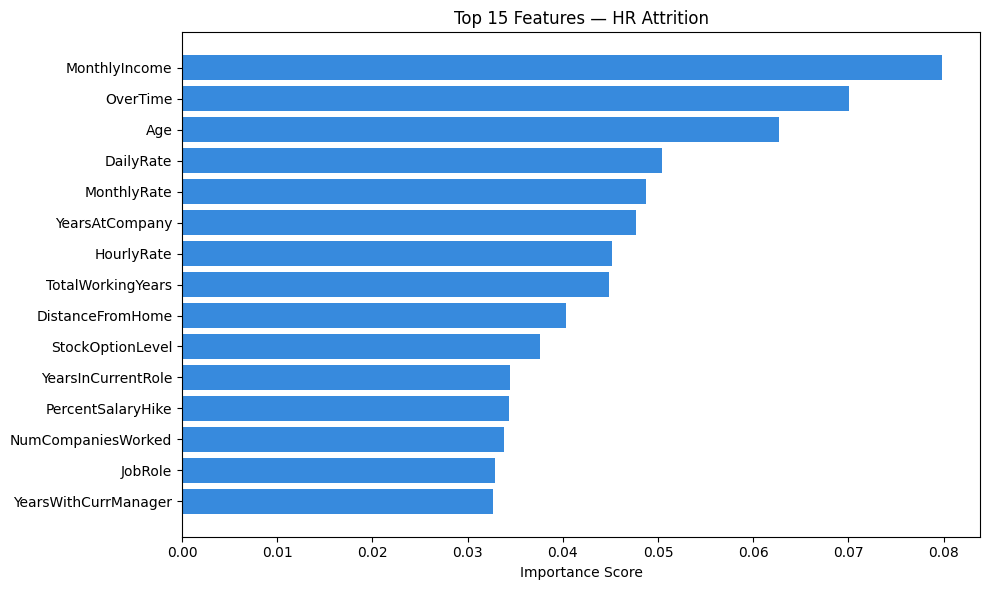


Top 10 Most Important Features:
1. MonthlyIncome: 8.0%
2. OverTime: 7.0%
3. Age: 6.3%
4. DailyRate: 5.0%
5. MonthlyRate: 4.9%
6. YearsAtCompany: 4.8%
7. HourlyRate: 4.5%
8. TotalWorkingYears: 4.5%
9. DistanceFromHome: 4.0%
10. StockOptionLevel: 3.8%


In [11]:
# Feature importance
feature_names = X.columns
importances = rf_model.feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1][:15]  # top 15

plt.figure(figsize=(10, 6))
plt.barh(range(15), importances[indices][::-1], color='#378ADD')
plt.yticks(range(15), [feature_names[i] for i in indices][::-1])
plt.xlabel('Importance Score')
plt.title('Top 15 Features — HR Attrition')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
for i in range(10):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]*100:.1f}%")

In [12]:
import pickle

# Save model
with open('hr_attrition_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save label encoders
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model saved! ✅")
print("Ready for Streamlit deployment!")

Model saved! ✅
Ready for Streamlit deployment!


In [13]:
import os
import pickle

# Create folder if it doesn't exist
os.makedirs('D:\\Shreyash_Projects\\HR-Attrition', exist_ok=True)

# Save model in correct folder
with open('D:\\Shreyash_Projects\\HR-Attrition\\hr_attrition_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Model saved in HR-Attrition folder! ✅")

Model saved in HR-Attrition folder! ✅
